In [2]:
!pip install pandas 


Defaulting to user installation because normal site-packages is not writeable


In [4]:
import pandas as pd 
df=pd.read_csv("covid_19_clean_complete.csv") #load data set 
df.head()


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [6]:
df.info()   
df.shape
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  str    
 1   Country/Region  49068 non-null  str    
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  str    
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  str    
dtypes: float64(2), int64(4), str(4)
memory usage: 3.7 MB


Index(['Province/State', 'Country/Region', 'Lat', 'Long', 'Date', 'Confirmed',
       'Deaths', 'Recovered', 'Active', 'WHO Region'],
      dtype='str')

In [8]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [9]:
df.dropna()  #drop the missing values 

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
8,Australian Capital Territory,Australia,-35.4735,149.0124,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.8688,151.2093,2020-01-22,0,0,0,0,Western Pacific
10,Northern Territory,Australia,-12.4634,130.8456,2020-01-22,0,0,0,0,Western Pacific
11,Queensland,Australia,-27.4698,153.0251,2020-01-22,0,0,0,0,Western Pacific
12,South Australia,Australia,-34.9285,138.6007,2020-01-22,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
49052,Anguilla,United Kingdom,18.2206,-63.0686,2020-07-27,3,0,3,0,Europe
49053,British Virgin Islands,United Kingdom,18.4207,-64.6400,2020-07-27,8,1,7,0,Europe
49054,Turks and Caicos Islands,United Kingdom,21.6940,-71.7979,2020-07-27,99,2,36,61,Europe
49059,Falkland Islands (Malvinas),United Kingdom,-51.7963,-59.5236,2020-07-27,13,0,13,0,Europe


In [10]:
df.dropna(axis=0) #drops the missing rows 

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
8,Australian Capital Territory,Australia,-35.4735,149.0124,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.8688,151.2093,2020-01-22,0,0,0,0,Western Pacific
10,Northern Territory,Australia,-12.4634,130.8456,2020-01-22,0,0,0,0,Western Pacific
11,Queensland,Australia,-27.4698,153.0251,2020-01-22,0,0,0,0,Western Pacific
12,South Australia,Australia,-34.9285,138.6007,2020-01-22,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
49052,Anguilla,United Kingdom,18.2206,-63.0686,2020-07-27,3,0,3,0,Europe
49053,British Virgin Islands,United Kingdom,18.4207,-64.6400,2020-07-27,8,1,7,0,Europe
49054,Turks and Caicos Islands,United Kingdom,21.6940,-71.7979,2020-07-27,99,2,36,61,Europe
49059,Falkland Islands (Malvinas),United Kingdom,-51.7963,-59.5236,2020-07-27,13,0,13,0,Europe


In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


In [15]:
country_case=df.groupby("Country/Region")["Confirmed"].sum()
print(country_case)

Country/Region
Afghanistan           1936390
Albania                196702
Algeria               1179755
Andorra                 94404
Angola                  22662
                       ...   
West Bank and Gaza     233461
Western Sahara            901
Yemen                   67180
Zambia                 129421
Zimbabwe                50794
Name: Confirmed, Length: 187, dtype: int64


In [16]:
df["mortality_rate"]=(df["Deaths"]/df["Confirmed"])*100
print (df[["Country/Region","mortality_rate"]])

#comparartory metrics  from third slide 

              Country/Region  mortality_rate
0                Afghanistan             NaN
1                    Albania             NaN
2                    Algeria             NaN
3                    Andorra             NaN
4                     Angola             NaN
...                      ...             ...
49063  Sao Tome and Principe        1.618497
49064                  Yemen       28.562980
49065                Comoros        1.977401
49066             Tajikistan        0.829302
49067                Lesotho        2.376238

[49068 rows x 2 columns]


In [18]:
agg=df.groupby("WHO Region")["Deaths"].agg(["sum","mean","max"])
print(agg)
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df.groupby("Month")["Confirmed"].sum()

                            sum         mean     max
WHO Region                                          
Africa                   439978    48.756427    7067
Americas               19359292  2238.586031  148011
Eastern Mediterranean   1924029   465.190764   15912
Europe                 19271040  1281.319149   45759
South-East Asia         1458134   775.603191   33408
Western Pacific          932430    90.176983    4512


Month
1        38534
2      1663437
3      9002815
4     63391662
5    144990399
6    246525787
7    362895848
Name: Confirmed, dtype: int64

In [20]:
df["7-Day Average"] = df["Confirmed"].rolling(7).mean()


In [21]:
print(df["7-Day Average"])

0                NaN
1                NaN
2                NaN
3                NaN
4                NaN
            ...     
49063    1234.857143
49064    1221.714286
49065     748.857143
49066    1780.571429
49067    1852.142857
Name: 7-Day Average, Length: 49068, dtype: float64


In [22]:
df["Cumulative Cases"] = df["Confirmed"].cumsum()

print(df[["Date", "Confirmed", "Cumulative Cases"]].head())

        Date  Confirmed  Cumulative Cases
0 2020-01-22          0                 0
1 2020-01-22          0                 0
2 2020-01-22          0                 0
3 2020-01-22          0                 0
4 2020-01-22          0                 0


In [23]:
df["Daily Change"] = df["Confirmed"].diff()

print(df[["Date", "Daily Change"]].head())

        Date  Daily Change
0 2020-01-22           NaN
1 2020-01-22           0.0
2 2020-01-22           0.0
3 2020-01-22           0.0
4 2020-01-22           0.0


In [24]:
def clean_data(file):
    df = pd.read_csv(file)

    df = df.fillna("Unknown")

    df["Mortality Rate"] = (
        df["Deaths"] / df["Confirmed"]
    ) * 100

    return df

In [25]:
df=clean_data("covid_19_clean_complete.csv")
df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region,Mortality Rate
0,Unknown,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean,NaN
1,Unknown,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe,NaN
2,Unknown,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa,NaN
3,Unknown,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe,NaN
4,Unknown,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa,NaN


In [ ]:
df.to_csv('final.csv')  
print ("file saved")

file saved


Defaulting to user installation because normal site-packages is not writeable


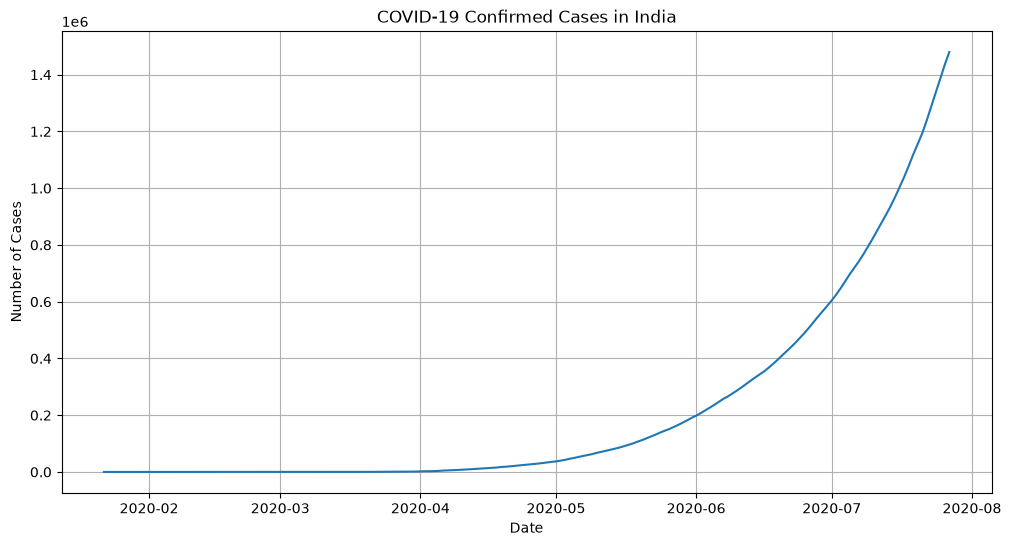

In [28]:
!pip install matplotlib
import matplotlib.pyplot as plt
# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])
india = df[df['Country/Region'] == 'India']
plt.figure(figsize=(12,6))
plt.plot(india['Date'], india['Confirmed'])
plt.title('COVID-19 Confirmed Cases in India')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.grid(True)
plt.show()

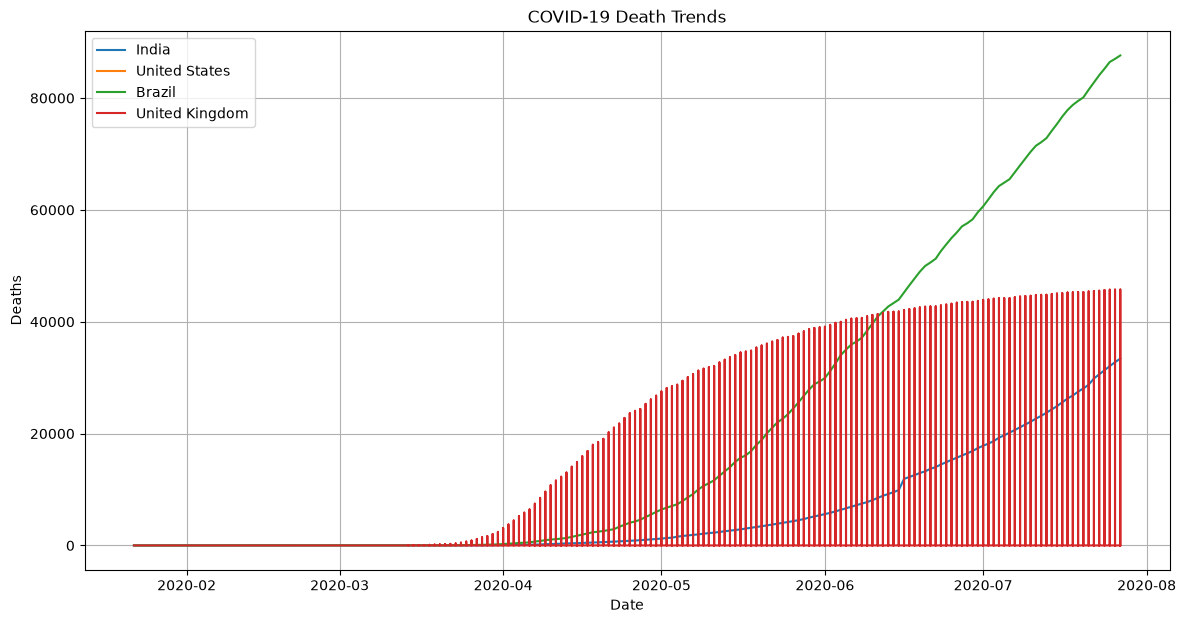

In [29]:
countries = ['India', 'United States', 'Brazil', 'United Kingdom']

plt.figure(figsize=(14,7))

for country in countries:
    data = df[df['Country/Region'] == country]
    plt.plot(data['Date'], data['Deaths'], label=country)

plt.title('COVID-19 Death Trends')
plt.xlabel('Date')
plt.ylabel('Deaths')
plt.legend()
plt.grid(True)
plt.show()

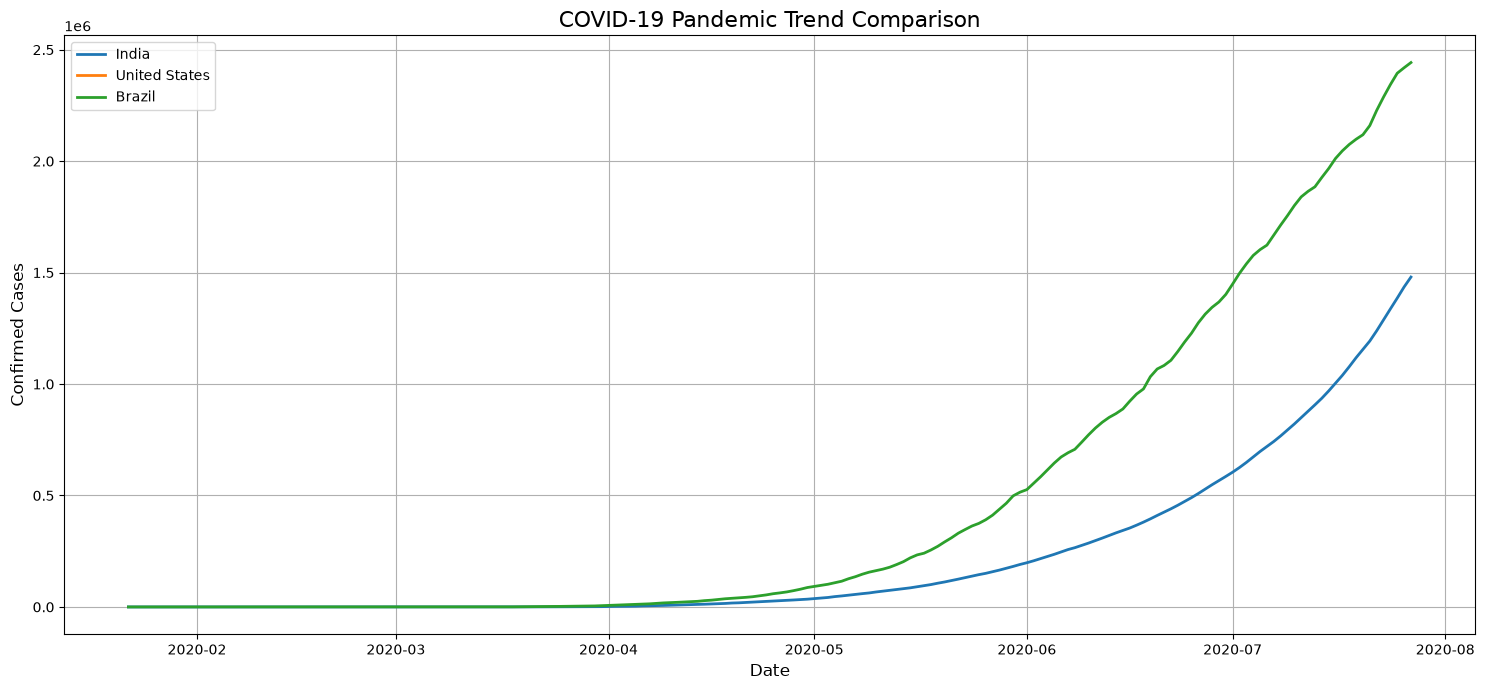

Empty DataFrame
Columns: [Province/State, Country/Region, Lat, Long, Date, Confirmed, Deaths, Recovered, Active, WHO Region, Mortality Rate]
Index: []


In [ ]:
plt.figure(figsize=(15,7))

for country in ['India', 'United States', 'Brazil']:
    temp = df[df['Country/Region'] == country]
    plt.plot(temp['Date'], temp['Confirmed'], linewidth=2, label=country)

plt.title('COVID-19 Pandemic Trend Comparison', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Confirmed Cases', fontsize=12)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
h = df[df["Country/Region"] == "United States"]

print(h)  